In [4]:
from google.colab import files
import os

uploaded = files.upload()

# Get the name of the uploaded file
terrain = list(uploaded.keys())[0]

# Unzip the file
!unzip -q "{terrain}"

print(f"Successfully unzipped {terrain}!")
#see the unzipped folder
!ls

Saving terrain.zip to terrain.zip
Successfully unzipped terrain.zip!
'Dataset 1.0'   sample_data   terrain.zip


In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2  # OpenCV for Canny
import os

base_dir = 'Dataset 1.0'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# Define image parameters
IMG_WIDTH = 256
IMG_HEIGHT = 256
BATCH_SIZE = 32

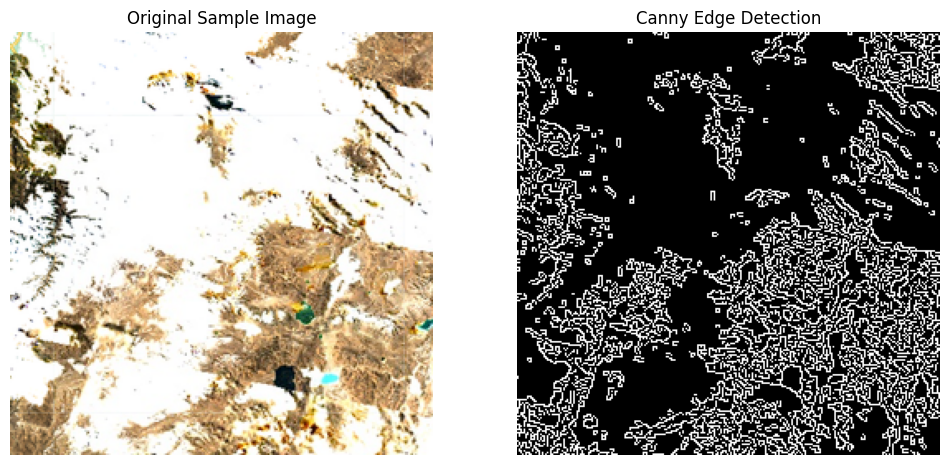

In [11]:
# Load a sample image to visualize
# This path now correctly uses your 'Dataset 1.0' folder
sample_path = os.path.join(train_dir, 'Mountains', 'M2_1.jpg')

# Check if the sample file exists before trying to read it
if os.path.exists(sample_path):
    img = cv2.imread(sample_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert for matplotlib

    # 1. Convert to grayscale for Canny
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Apply Canny edge detection
    edges = cv2.Canny(gray_img, 100, 200)

    # 3. Plot the results
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title('Original Sample Image')
    plt.imshow(img_rgb)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Canny Edge Detection')
    plt.imshow(edges, cmap='gray')
    plt.axis('off')

    plt.show()
else:
    print(f"Error: Sample file not found at {sample_path}")
    print("Please check the folder names inside 'Dataset 1.0/train/'")

In [12]:
# 1. Create a data generator for the TRAINING set
#    This includes normalization (rescale) and augmentation
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,            # Normalize pixel values from [0, 255] to [0, 1]
    rotation_range=20,       # Randomly rotate images
    width_shift_range=0.2,   # Randomly shift images horizontally
    height_shift_range=0.2,  # Randomly shift images vertically
    shear_range=0.2,         # Apply shear transformations
    zoom_range=0.2,          # Randomly zoom in on images
    horizontal_flip=True,    # Randomly flip images horizontally
    fill_mode='nearest'      # Strategy for filling in new pixels
)

# 2. Create a data generator for VALIDATION and TEST sets
#    IMPORTANT: Do NOT augment this data. Only normalize it.
val_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255  # Only normalize
)

In [15]:
# Load images from directories and apply the pre-processing
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Do not shuffle test data; keep it in order
)

# Check the class indices (should show 'Deserts', 'Forest Cover', 'Mountains')
print(f"Class indices found: {train_generator.class_indices}")

Found 6006 images belonging to 3 classes.
Found 585 images belonging to 3 classes.
Found 585 images belonging to 3 classes.
Class indices found: {'Deserts': 0, 'Forest Cover': 1, 'Mountains': 2}


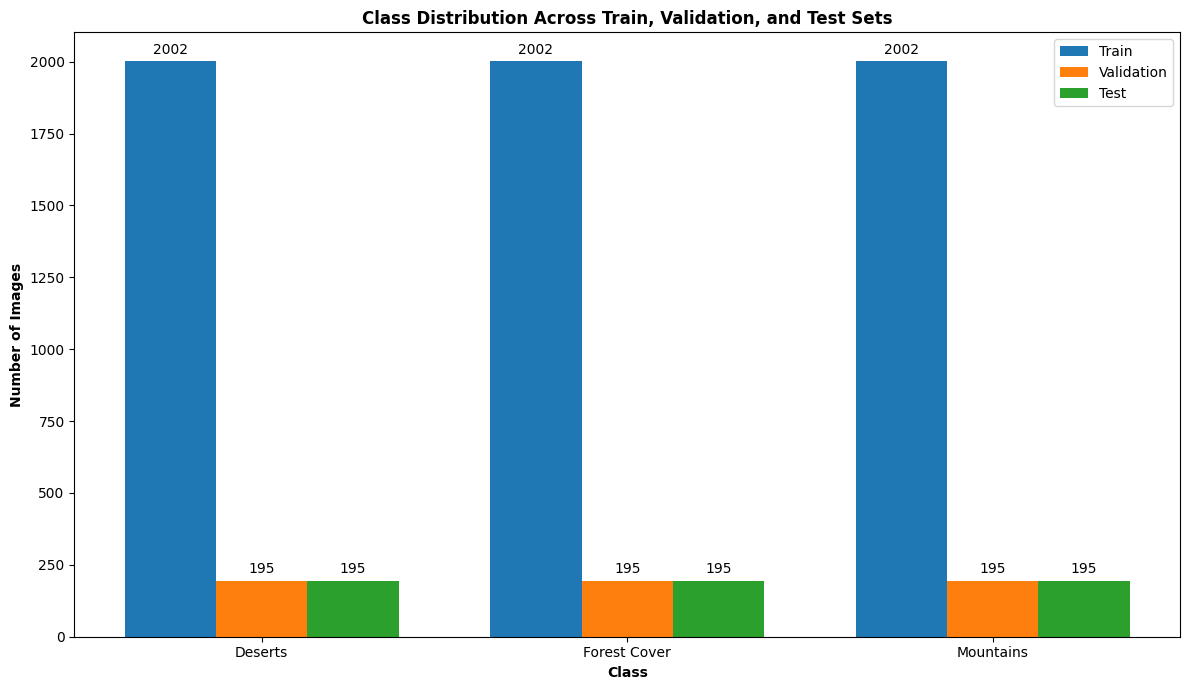

Classes found: ['Deserts', 'Forest Cover', 'Mountains']
Train counts: [2002, 2002, 2002]
Validation counts: [195, 195, 195]
Test counts: [195, 195, 195]


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_dir = 'Dataset 1.0'
sets_to_plot = ['train', 'validation', 'test']
classes = sorted(os.listdir(os.path.join(base_dir, 'train')))

# 1. Count the files
counts = {}
for s in sets_to_plot:
    set_counts = []
    set_path = os.path.join(base_dir, s)
    for c in classes:
        class_path = os.path.join(set_path, c)
        count = len(os.listdir(class_path))
        set_counts.append(count)
    counts[s] = set_counts

# 2. Plot the grouped bar chart
n_classes = len(classes)
index = np.arange(n_classes)
bar_width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

# Plot bars for each set
bar1 = ax.bar(index - bar_width, counts['train'], bar_width, label='Train')
bar2 = ax.bar(index, counts['validation'], bar_width, label='Validation')
bar3 = ax.bar(index + bar_width, counts['test'], bar_width, label='Test')

# Add labels and title
ax.set_xlabel('Class', fontweight='bold')
ax.set_ylabel('Number of Images', fontweight='bold')
ax.set_title('Class Distribution Across Train, Validation, and Test Sets', fontweight='bold')
ax.set_xticks(index)
ax.set_xticklabels(classes)
ax.legend()

# Add counts on top of the bars
ax.bar_label(bar1, padding=3)
ax.bar_label(bar2, padding=3)
ax.bar_label(bar3, padding=3)

fig.tight_layout()
plt.show()

# Print the counts
print(f"Classes found: {classes}")
print(f"Train counts: {counts['train']}")
print(f"Validation counts: {counts['validation']}")
print(f"Test counts: {counts['test']}")

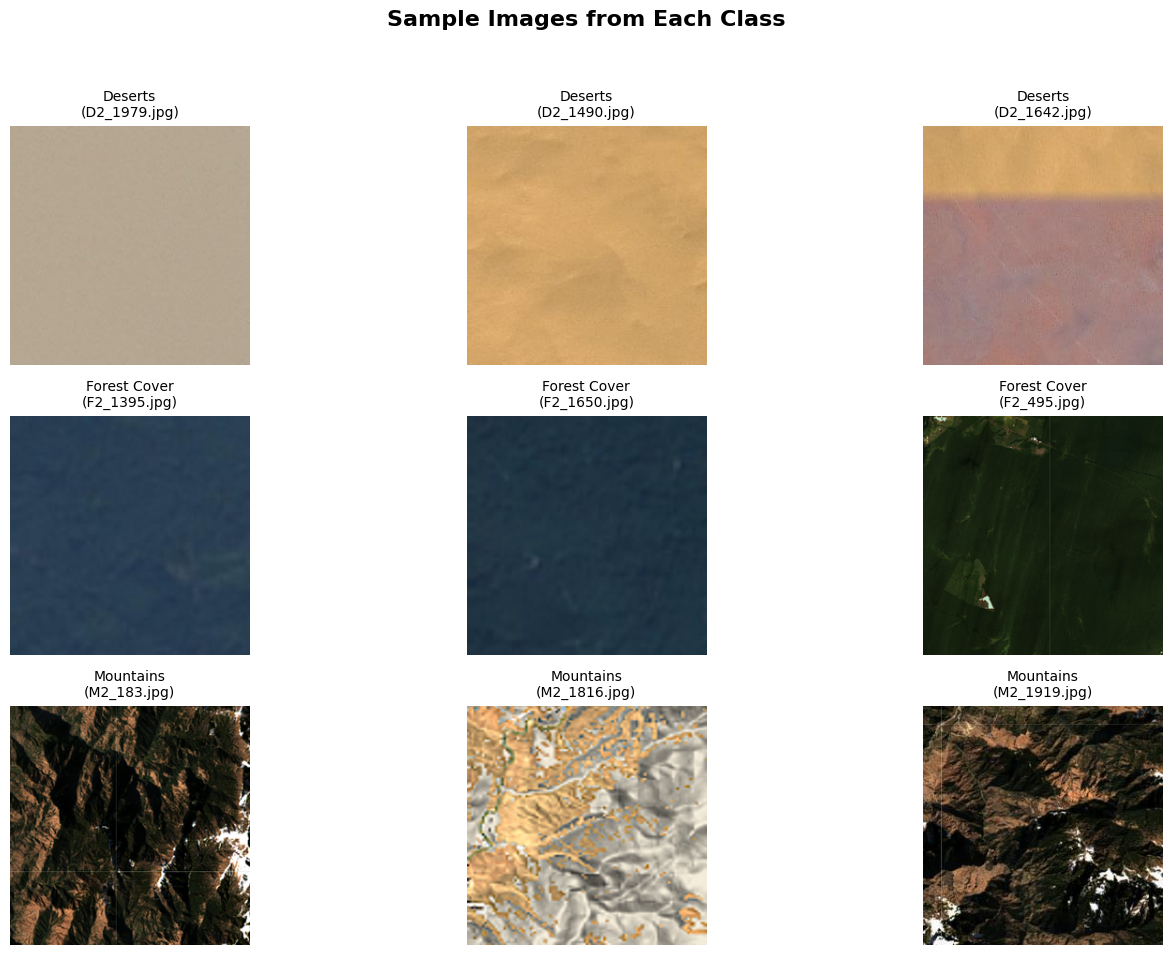

In [17]:
import random

train_dir = os.path.join(base_dir, 'train')
classes = sorted(os.listdir(train_dir))

num_samples_per_class = 3

plt.figure(figsize=(15, 10))
plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold')

# Loop over each class
for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    all_images = os.listdir(class_path)

    # Pick N random images
    sample_images = random.sample(all_images, num_samples_per_class)

    # Plot the N random images
    for j, image_name in enumerate(sample_images):
        img_path = os.path.join(class_path, image_name)

        # plt.imread which loads as RGB
        img = plt.imread(img_path)

        ax = plt.subplot(len(classes), num_samples_per_class, i * num_samples_per_class + j + 1)

        plt.imshow(img)
        plt.title(f"{class_name}\n({image_name})", fontsize=10)
        plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
plt.show()

In [18]:
import os
import cv2

train_dir = 'Dataset 1.0/train'
classes = sorted(os.listdir(train_dir))

print("Running Image Dimensions & Channel Check...")
print("-" * 30)

# Store all unique shapes found
shapes = {}
total_images = 0

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    all_images = os.listdir(class_path)
    print(f"Checking {len(all_images)} images in class: {class_name}")

    for image_name in all_images:
        img_path = os.path.join(class_path, image_name)

        # Read image with OpenCV to get its shape
        img = cv2.imread(img_path)

        # Check if image loaded correctly
        if img is None:
            print(f"  WARNING: Could not read image: {img_path}")
            continue

        shape_str = str(img.shape)

        # Add shape to our dictionary
        if shape_str in shapes:
            shapes[shape_str] += 1
        else:
            shapes[shape_str] = 1

        total_images += 1

print("-" * 30)
print(f"Check complete. Processed {total_images} images.")
print("\nUnique Image Shapes Found:")
for shape, count in shapes.items():
    print(f"  Shape: {shape}  - Count: {count}")

if len(shapes) == 1 and '(256, 256, 3)' in shapes:
    print("\nResult: PASSED! All images are 256x256 with 3 color channels.")
else:
    print("\nResult: WARNING! Inconsistent image dimensions or channels found.")

Running Image Dimensions & Channel Check...
------------------------------
Checking 2002 images in class: Deserts
Checking 2002 images in class: Forest Cover
Checking 2002 images in class: Mountains
------------------------------
Check complete. Processed 6006 images.

Unique Image Shapes Found:
  Shape: (256, 256, 3)  - Count: 6006

Result: PASSED! All images are 256x256 with 3 color channels.


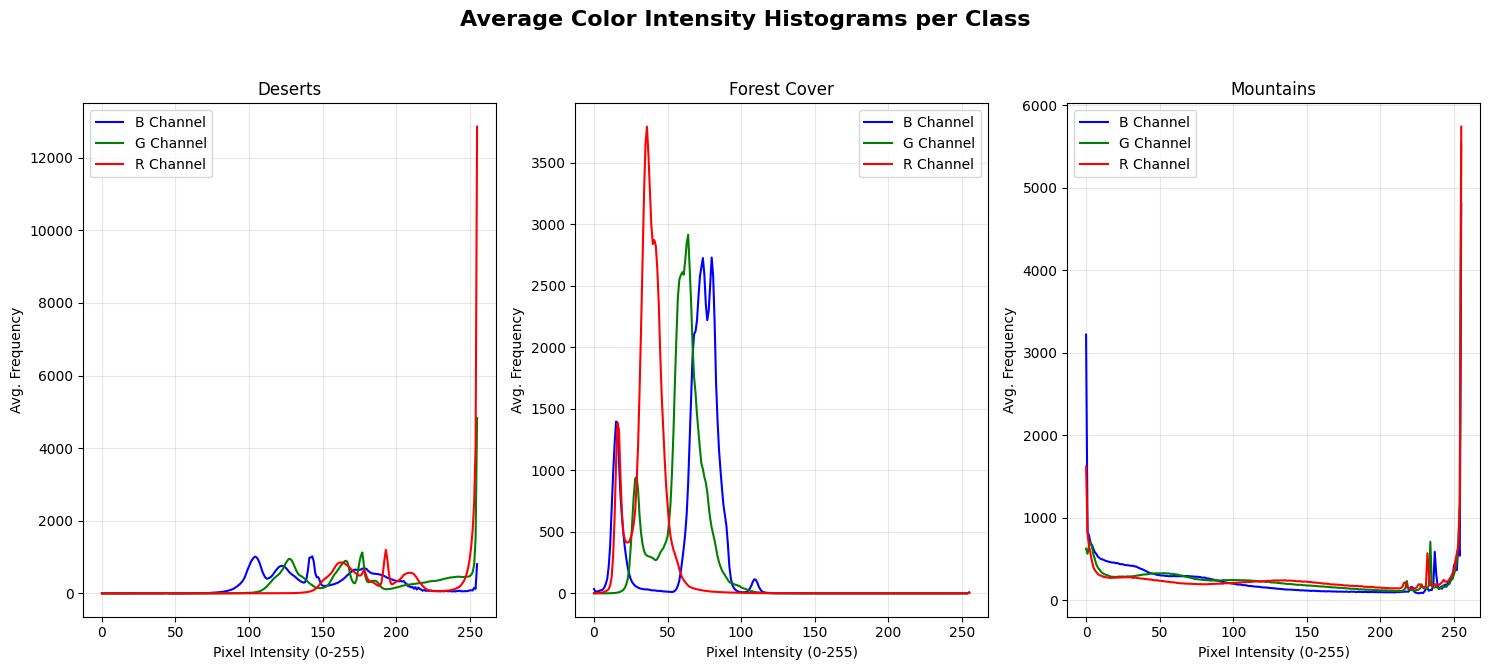

In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


train_dir = 'Dataset 1.0/train'
classes = sorted(os.listdir(train_dir))
colors = ('b', 'g', 'r') # OpenCV uses BGR order

plt.figure(figsize=(15, 7))
plt.suptitle('Average Color Intensity Histograms per Class',
             fontsize=16, fontweight='bold')

# Loop over each class
for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    all_images = os.listdir(class_path)

    # We will average the histograms
    # (3 channels, 256 bins)
    avg_hist = np.zeros((3, 256))

    # Sample 100 images per class (to run faster)
    sample_images = np.random.choice(all_images, 100, replace=False)

    for image_name in sample_images:
        img_path = os.path.join(class_path, image_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # Calculate histogram for each channel (b, g, r)
        for j, col in enumerate(colors):
            hist = cv2.calcHist([img], [j], None, [256], [0, 256])
            avg_hist[j] += hist.flatten()

    # Get the average histogram
    avg_hist = avg_hist / len(sample_images)

    # Plot the histograms for this class
    ax = plt.subplot(1, len(classes), i + 1)
    for j, col in enumerate(colors):
        ax.plot(avg_hist[j], color=col, label=f'{col.upper()} Channel')

    ax.set_title(class_name)
    ax.set_xlabel('Pixel Intensity (0-255)')
    ax.set_ylabel('Avg. Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Calculating average image per class... (This may take a minute)
Done.


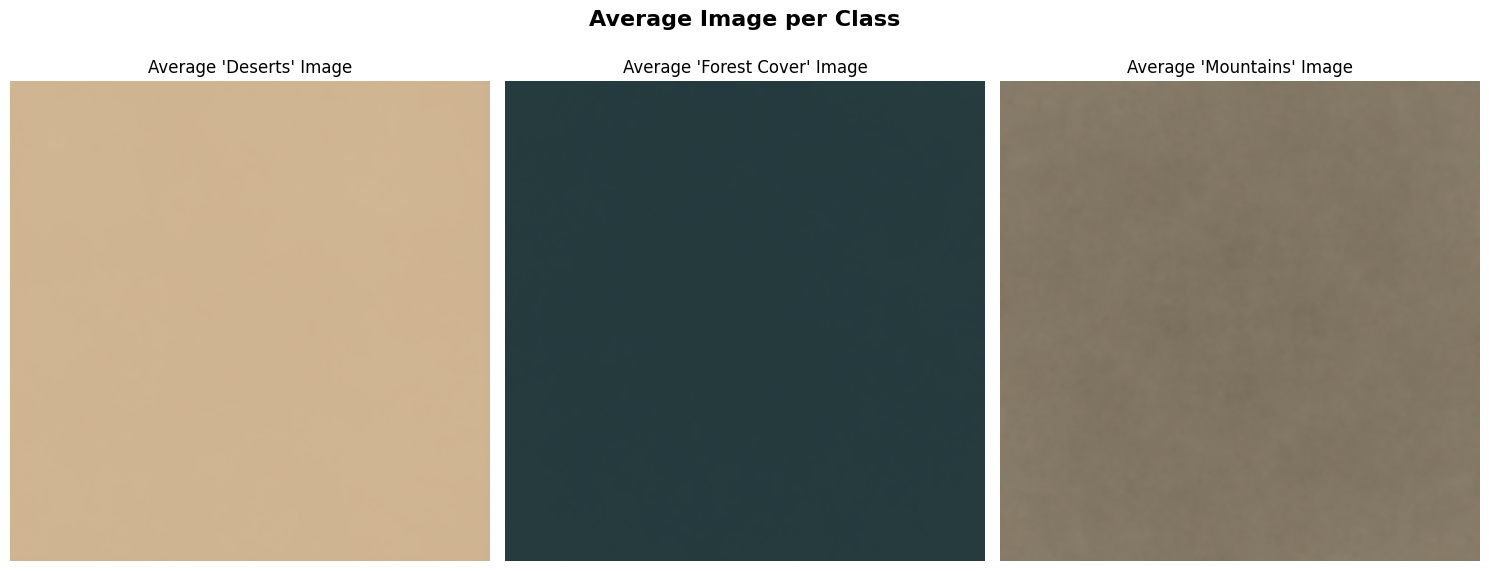

In [20]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


train_dir = 'Dataset 1.0/train'
classes = sorted(os.listdir(train_dir))
IMG_HEIGHT, IMG_WIDTH = 256, 256

print("Calculating average image per class... (This may take a minute)")

plt.figure(figsize=(15, 6))
plt.suptitle('Average Image per Class', fontsize=16, fontweight='bold')

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    all_images = os.listdir(class_path)

    # Use a high-precision accumulator (float64)
    avg_image = np.zeros((IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float64)

    num_images = 0
    for image_name in all_images:
        img_path = os.path.join(class_path, image_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # Resize just in case (though your check should pass)
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        # Add to the accumulator
        avg_image += img
        num_images += 1

    # Calculate the average
    if num_images > 0:
        avg_image = avg_image / num_images

    # Convert back to 8-bit (0-255) for display
    # and convert from BGR (cv2) to RGB (plt)
    avg_image_display = cv2.cvtColor(avg_image.astype(np.uint8), cv2.COLOR_BGR2RGB)

    # Plot
    ax = plt.subplot(1, len(classes), i + 1)
    ax.imshow(avg_image_display)
    ax.set_title(f"Average '{class_name}' Image")
    ax.axis('off')

print("Done.")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()